# 03 高さ（運動学のしゃがみ、そのあと高さ P）

## 背景

02 では \(F_z = mg/4\) で体重を支えた。静力学の和は重量と釣り合うだけで、**高さの目標が入っていない**。だから EqualShare のままでは、胴体 z を指令できない。

本段はフェーズ 0 の 4（[00 README](../docs/block-curriculum/00_README.md) §7、[02](../docs/block-curriculum/02_Stage_Ladder.md) の S2）。予測最適化はまだ書かない。

## 目的

- **A（運動学）**: 目標関節を補間して、公称と約 −3 cm を往復する。転倒しない
- **B（力）**: \(\sum F_z = mg + k_p(z^{\mathrm{ref}}-z) - k_d \dot z\) を立脚で割る。指令 z に遅れてついていく様子をグラフと GIF で見る
- 白矢印は指令 GRF（A には無い）。色矢印は実接触。混ぜない

B の追従が悪い・沈むのは失敗ではなく、「高さは S1 の力だけでは追えない」観察である。ここで NMPC を足さない。

## 数式

A は関節の線形補間と PD である。

\[
q^{\mathrm{des}}(t) = (1-s)\,q_{\mathrm{stand}} + s\,q_{\mathrm{squat}},\qquad
\tau = k_p(q^{\mathrm{des}}-q) - k_d \dot q
\]

B は [04](../docs/block-curriculum/04_Force_Without_Mpc.md) の高さ P である。

\[
\sum_i F_{z,i} = mg + k_p(z^{\mathrm{ref}}-z) - k_d \dot z,\qquad
\tau = -J^\top F
\]

## 図

```
A: q_stand --lerp--> q_squat --> joint PD --> clip --> MuJoCo

B: z, z_ref --> height_p_share --> Grf -- map_jt --> clip --> MuJoCo
                 (white = command GRF)
```


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


/home/takuya/work/mpc_dog/notebook/assets/03_height_kinematic.gif 2849657 bytes


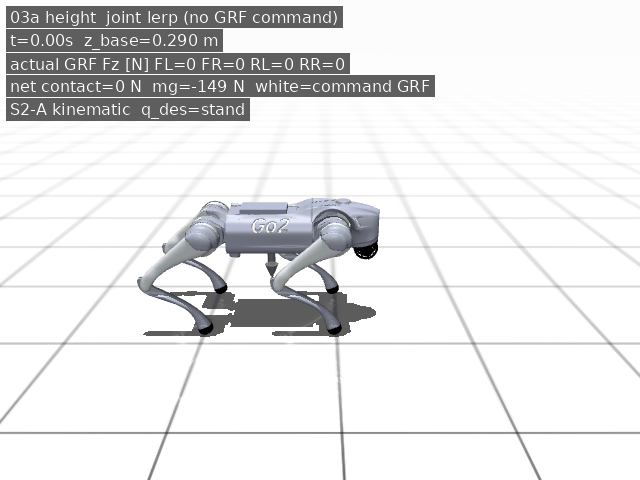

In [1]:
from pathlib import Path
import sys
from IPython.display import Image, display
import matplotlib.pyplot as plt

here = Path.cwd().resolve()
for p in [here, *here.parents]:
    if (p / "src" / "mpc_dog").is_dir():
        sys.path.insert(0, str(p / "src"))
        break

from mpc_dog.force.demo_height import run_height_kinematic_demo, run_height_p_demo

gif_a = Path("assets/03_height_kinematic.gif")
path_a, log_a = run_height_kinematic_demo(gif_a)
print(path_a.resolve(), path_a.stat().st_size, "bytes")
display(Image(filename=str(path_a)))


/home/takuya/work/mpc_dog/notebook/assets/03_height_p.gif 2869030 bytes


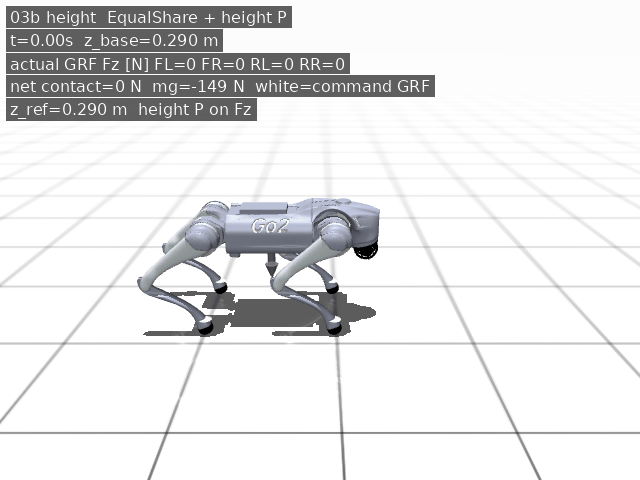

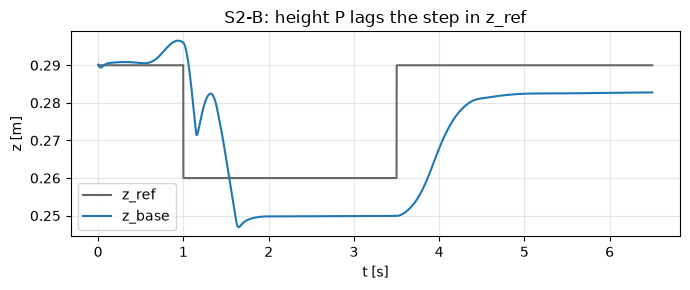

In [2]:
gif_b = Path("assets/03_height_p.gif")
path_b, log_b = run_height_p_demo(gif_b)
print(path_b.resolve(), path_b.stat().st_size, "bytes")
display(Image(filename=str(path_b)))

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(log_b["t"], log_b["z_ref"], label="z_ref", color="0.4")
ax.plot(log_b["t"], log_b["z"], label="z_base", color="C0")
ax.set_xlabel("t [s]")
ax.set_ylabel("z [m]")
ax.set_title("S2-B: height P lags the step in z_ref")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()


## 結果の読み方

- A: 関節を折ると胴体が下がる。白矢印は無い（指令 GRF を出していない）
- B: 白矢印の長さが \(z^{\mathrm{ref}}\) に応じて少し変わる。実高さは指令に遅れる／足りなくてよい
- 次は周期ゲイトで足を上げる。立脚はまだ \(J^\top F\)
